# Introduction to 2D Grayscale and Color Images

__Author(s):__ Masa Prodanovic

__Last Update:__ Sep. 2025

Copyright © 2025 Digital Porous Media Team. All rights reserved.

---



Images are all around us, and most computers, including your phone, can very easily process them.

Most often they are color images (such as taken by your phone or camera) and most often, the end objective is beauty, art, sharing on social media or some emotional value. Thus image processing for that type of objective is not necessarily careful about distorting original image values.

If the ultimate objective is scientific, we have to be mindful of how values are stored or manipulated.

## Color vs. grayscale images
Storing color requires specific handling, and one way called RGB is to store three images that mix red (R), green (G) and blue (B) colors. 

Each of the RGB channels has numerical values between 0 and 255 (1 byte / 8 bits)/ of data each); sometimes these are stored is so-called 24-bit  RGB format. Other possibilities are HSV and hexadecimal format (often used in webpages). 
- You can play with all of the formats [on the following webpage](https://www.rapidtables.com/web/color/RGB_Color.html)


- Test burnt orange color with [RGB values (191, 87, 0) or (191/255,87/255,0)](https://brand.utexas.edu/identity/color/)

Grayscale images simply have all three R,G,B the same (check by inputting 191,191,191 and 87,87,87 on the webpage above). Thus they are simply represented by a single value (single image).

## Digital Rock Physics images

In digital rocks physics, images simply depict (or correlate) with a measurement. In X-ray imaging, there is a single measurement of an x-ray attenuation factor (its absolute value is not always meaningful unless calibrated, this is done in medical CT, but not in microtomography). Thus they are mostly shown as grayscale (they also get very large, so storing color images is too expensive). Any *appearance of color is just for beauty*, i.e. it is fake color.

- [Example grayscale SEM sandstone image (2D)](https://digitalporousmedia.org/published-datasets/tapis/projects/drp.project.published/drp.project.published.DRP-256/Plug%20130/Plug%20130%20SEM/plug_130_image_23-0.png.thumb.jpg)

- [Example grayscale x-ray microtomography images of limestone (3D)](https://digitalporousmedia.org/published-datasets/tapis/projects/drp.project.published/drp.project.published.DRP-125)

In optical imaging, such as done for thin sections, the color is true (i.e. the one we see with our eyes). 

- [Example true color image:](https://digitalporousmedia.org/published-datasets/tapis/projects/drp.project.published/drp.project.published.DRP-244/)

However, we can choose a color for any specific numerical value (or range of values) and get "fake" color.
- [Example fake color images are created by choosing a color map for velocity field values](https://digitalporousmedia.org/published-datasets/tapis/projects/drp.project.published/drp.project.published.DRP-175)

## Python and image processing

Images are 1D, 2D, 3D arrays and are best processed as NumPy arrays, since that allows scientific computation on them. Since computer memory is limited, we have different ways of storing integers and real numbers, and that is important to understand in any kind of scientific application (images included). __We assume basic knowledge of Python and NumPy; the set of fully worked out examples should speed you up in using NumPy for the purpose of image manipulation. I adapted the examples found on the web here to digital rock physics.

- __Skimage__: We will work here with __scikit-image (a.k.a. [skimage](https://scikit-image.org/)) distribution built on top of NumPy and SciPy that comes in most scientific Python environments, including Anaconda.
- There are numerous places that introduce skimage. One suggestion is linked [here](
https://scipy-lectures.org/packages/scikit-image/#scikit-image-and-the-scipy-ecosystem).
- The full list of modules in skimage is available as an [API reference](https://scikit-image.org/docs/stable/api/api.html) 

- Other general image libraries in Python are __PIL/Pillow__ and __OpenCV2__. I presently find skimage to be more mature, and more numpy friendly. __Note that the software space constantly changes.__

- [PoreSpy software](https://joss.theoj.org/papers/10.21105/joss.01296) for image processing in porous media is relatively new and worth checking out since it is linked to various simulation tools for porous media 

## Check for and install packages used in this notebook

This notebook depends on __numpy, matplotlib, scikit-image and plotly.__


In [ ]:
import skimage
import plotly

C:\ProgramData\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


## Image processing outside Python
- [MATLAB image processing](https://www.mathworks.com/products/image-processing.html) is mature, alas paid license is necessary.
- [Fiji/ImageJ](https://imagej.net/Fiji), open source. Many image processing algorithms are implemented and GUI works well which is great for testing things out. From the automation (scripting) point of view it is not ideal, but Python is available as a scripting language.

# Examples 
## Example 1: interpreting NumPy 2D arrays as images
In this example, we will create a simple 3 by 5 array and show it visually on the screen.
We will start with an image of 0's and 1's.

- NumPy has a range of commands that initialize arrays of any dimension: e.g. numpy.zeros (shown below), numpy.ones, numpy.random.rand 
- Full list of functions for ndarrays can be found here:
https://numpy.org/doc/stable/reference/generated/numpy.ndarray.html
- _matplotlib.pyplot.imshow_ command from the omnipresent Matplotlib module is used for showing 2D images


In [3]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt

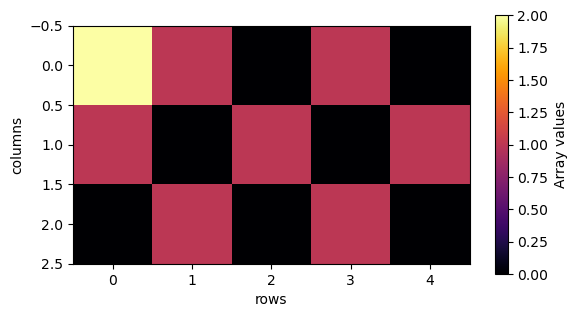

In [5]:
# Initialize all of the 3 by 5 array/matrix as zeros.
# (3, 5) is shape of the array - (nrows, ncols)
check = np.zeros((3, 5))

# Option 1: literal way to define an array
check = np.array([ [0,1,0,1,0],[1,0,1,0,1],[0,1,0,1,0] ])

## Option 2 for definining a checkerboard that can easily scale to any size: Recall that you can 'slice' any dimension of the 
## array using 'start:stop:step' framework (and step is optional) where start, stop, step are indices
## - If you omit start, stop or step, that implies all of them will be included.
## - Array indices in Python start from 0 (in MATLAB they start from 1)
##
## Set to 1 every second element in row dimension AND every second starting from 1 in the column dimension
#check[::2, 1::2] = 1 
## Set to 1 every second element in row dimension starting from element 1 AND every second in column dimension
#check[1::2, ::2] = 1

check[0,0]=2

#  the color map is set to 'gray', change the colormap to 'summer' or 'viridis' to see some other options
plt.imshow(check,cmap='inferno')
plt.xlabel('rows')
plt.ylabel('columns')

cbar = plt.colorbar(shrink=0.7)  # Add colorbar and shrink it to the given fraction of the original
cbar.set_label('Array values')

### Exercises:
1.  Check what happens if you change cmap to 'summer' in plt.imshow command, or if you remove cmap part of command altogether.
2.  Which corner of the image does  (0,0) element of the image origin start? Is that the same as we plot the Cartesian coordinate system? 
3.  Set element check[0,0] to 2 in order to visualize the origin of the image, and notice how that shifts the colors in the image.

## Example 2: reading and analyzing any image available online
Download Digital Porous Media Portal cover image and show it.

Key commands:
- skimage.io.imread
- matplotlib.pyplot.imshow

As long as you know the address of the target image, this can be easily reproduced for any other image:

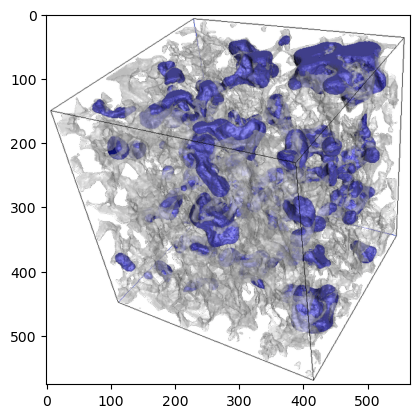

In [7]:
import skimage
from skimage import io

# This is a small image test with the cover image from Digital Porous Media Portal
cover_url = 'https://digitalporousmedia.org/media/filer_public_thumbnails/filer_public/7d/3b/7d3ba264-8945-4211-9eca-0a15c8a9fa17/cover-image.png__576x576_subsampling-2.png'
cover_img = io.imread(cover_url)
plt.imshow(cover_img)


Instead of the cover_url above, you can provide a filename (including the directory path) to an image downlaoded on your computer.
- On my current laptop this defaults to:
    download_path = "C:\Users\masha\Downloads\cover_image.png"
- If the image is in the same directory as the code, then you need only  "cover_image.png" as the name of the file.

## Example 3: Binarized (segmented) image of a disk packing

This image has only two values - when you show the image, it will show only two colors (e.g. black and white)
Such images are called binarized or segmented. In this case, this is a 2D slice through a disordered glass bead pack 3D image, part of [Network Comparison forum dataset](https://digitalporousmedia.org/published-datasets/tapis/projects/drp.project.published/drp.project.published.DRP-16)


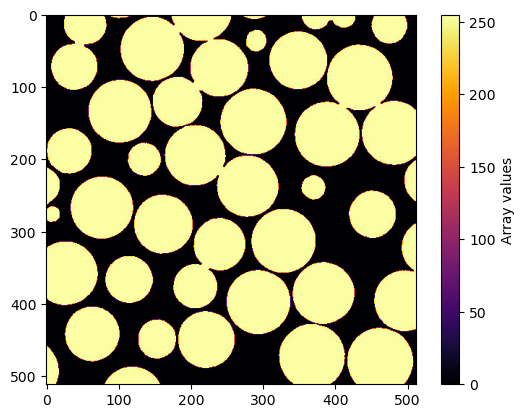

In [ ]:
imgurl = r'https://web.corral.tacc.utexas.edu/digitalporousmedia/DRP-16/Silice%20sphere%20pack/Glass%20Bead%20Pack%20(unconsolidated)/segmented_bead_pack_512.ubc.jpg'
img = io.imread(imgurl)
plt.imshow(img,cmap='inferno')
cbar = plt.colorbar()
cbar.set_label('Array values')

## Example 4: Grayscale sandstone image (x-ray microtomography slice)

X-ray microtomography results in images that have values that scale with the density of material. In this case we see sandstone grains (mostly silica) and pore (empty) space. There is always some inherent noise in the images due to both the interaction of x-ray with different types of material, the level of detail (how small are the distances we are trying to resolve) and reconstruction of the 3D images from projections.

Example from [dataset by Da Wang et al](https://digitalporousmedia.org/published-datasets/tapis/projects/drp.project.published/drp.project.published.DRP-211).


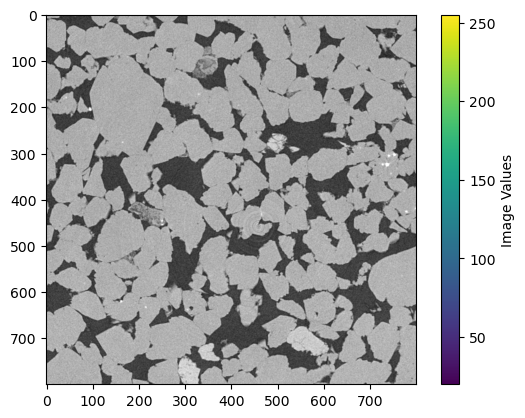

In [ ]:
imgurl  = 'https://web.corral.tacc.utexas.edu/digitalporousmedia/DRP-211/Sandstone%20Example%20Images/Sandstone%20Example%20Images/0801.png'
img = io.imread(imgurl)

fig, ax = plt.subplots()  # being specific about figure, axes 
imobj = ax.imshow(img)  # being ecific about imshow object, so that colobar does not get confused with the previous one
fig.colorbar(imobj, ax=ax, label='Image Values')
plt.show()


## Basic inspection of the image

One needs to be aware of it, as a lot of error in scientific visualization or image processing can result from not understanding what numbers are you working with. 

The image is read into a NumPy ndarray. 

- __Image size:__ have to know it or it can cause a lot of drama (see above)!
- __Image data type:__ some functions might be programmed to work only with integers or floats. Color mode (such as RGB) takes three times the space and storage. If you do not use functions appropriately, you will get garbage output.
Different integer data types are possible: 8-, 16- or 32-bytes, signed or unsigned (start with 'u').
- __Basic stats__: min, maximum, average of values (and even better, image histogram)



In [19]:
print('\nImage size',img.size, '-- in megabytes this is approximately',img.size/1000000,'MB.')
print('\nImage (ndarray) shape',img.shape)
print('\nImage data type',img.dtype)


Image size 1920000 -- in megabytes this is approximately 1.92 MB.

Image (ndarray) shape (800, 800, 3)

Image data type uint8


## Notes
Note that this image has values as 800 by 800 by 3. Since it is shown as gray image above (without specififying gray colormap), this means it is stored as a color image with all three values corresponding to red, green and blue channels the same value.

With that in mind, we use only one channel below and reshape the array in order to inspect basic statistics about these values.

Image max 255

Image values min:20.00

Image values max:255.00

Image values mean:148.17


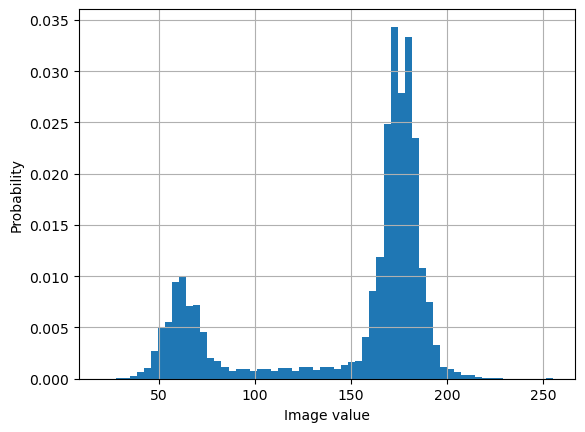

In [11]:
# This is a 2D image, and min, max and mean functions are programmed to work by dimension. 
# So we will reshape the array. 
# Be mindful that below we are on purpose creating another copy of the array (and doubles the memory use)
nrows,ncols,extra = img.shape;
reshaped_img = np.copy(img[:,:,0]) #keep only the first channel of data
reshaped_img.shape = (nrows*ncols,) # reshape for histogram

# min, max, mean are functions that are built into ndarray class in NumPy. If we call them such as in example below,
# then they will execute on the ndarray reshaped_image
imin = reshaped_img.min()
imax = reshaped_img.max()
imean = reshaped_img.mean()
print('Image max',imax)
print(f"\nImage values min:{imin:.2f}")
print(f"\nImage values max:{imax:.2f}")
print(f"\nImage values mean:{imean:.2f}")

#Histogram
# The range of values has 256 possible values (0 though 256), I am choosing a fraction of that as number of bins.
# histogram below is also normalized (density=True)
nbins = 64
plt.hist(reshaped_img, nbins, density=True)

plt.xlabel('Image value')
plt.ylabel('Probability')

#adds text in a specific location
#plt.text(50, .025, 'Any comment') 

# crop axes
#plt.axis([30, 240, 0, 0.035]) 
plt.grid(True)
plt.show()


### __Extra: Customizing color in matplotlib__

matplotlib gives you 4 ways to specify colors,

    1) as a single letter string, like MATLAB

    2) as an html style hex string or html color name

    3) as an R,G,B tuple, where R,G,B, range from 0-1

    4) as a string representing a floating point number
       from 0 to 1, corresponding to shades of gray.

See help(colors) for more info.

Below you will see example of setting the color of the histogram to burnt orange (R,G,B values are 191, 87, 0, respectively). 


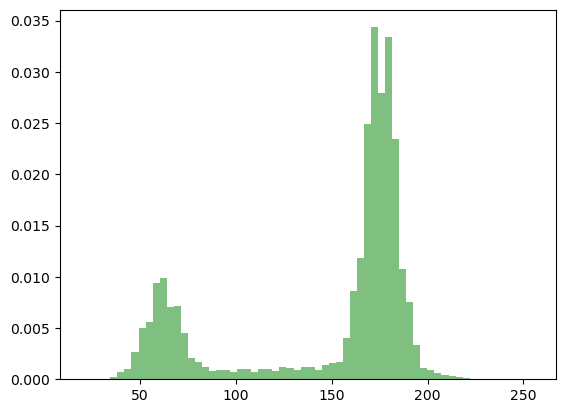

In [23]:

# uncomment and comment all therese versions to try them out
#plt.hist(reshaped_img, nbins, density=True, facecolor='g') #green color letter string
plt.hist(reshaped_img, nbins, density=True, facecolor='g',alpha = 0.5)  # green color with transparency alpha set to 0.5 (put a value between 0 and 1)
#plt.hist(reshaped_img, nbins, density=True, facecolor='#FF0000') # this is hex string denoting true red, letter 'r' works the same
#plt.hist(reshaped_img, nbins, density=True, facecolor=(191/255,87/255,0), alpha=0.75) #RGB corresponding to burnt orange

plt.show()

### __Color images__

Color images are of shape (N, M, 3) or (N, M, 4). Note that the fourth, 'alpha', channel encodes transparency (if used).
                                                  
Routines converting between different colorspaces (RGB, HSV, LAB etc.) are available 
in skimage.color : color.rgb2hsv, color.lab2rgb, etc. 
                                                  
Example below inspects a true color image (microscopy of a thin section of an Offshore Miocene sandstone). Note that blue in thin sections of rocks is epoxy that fills up the pore spaces and enables us to quantify porosity.

Text(0.5, 1.0, 'Offshore Miocene Sandstone thin section microscopy image')

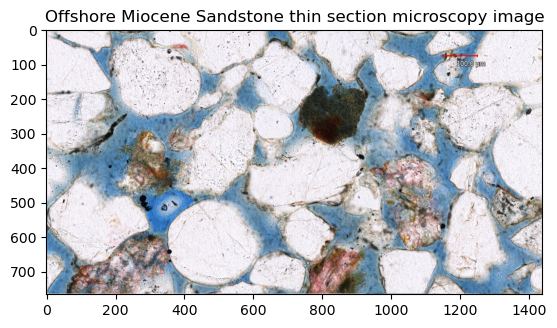

In [25]:
imgurl = 'https://web.corral.tacc.utexas.edu/digitalporousmedia/DRP-244/Offshore%20miocene%20sandstone/Imaged%20thin%20sections/OffshoreMiocene_20.jpx_0.25x_11960_18963_ppl.jpg'
img = io.imread(imgurl)
plt.imshow(img)
plt.title('Offshore Miocene Sandstone thin section microscopy image')

(766, 1438, 3)
3304524
uint8


Text(0.5, 0, 'Image value bins')

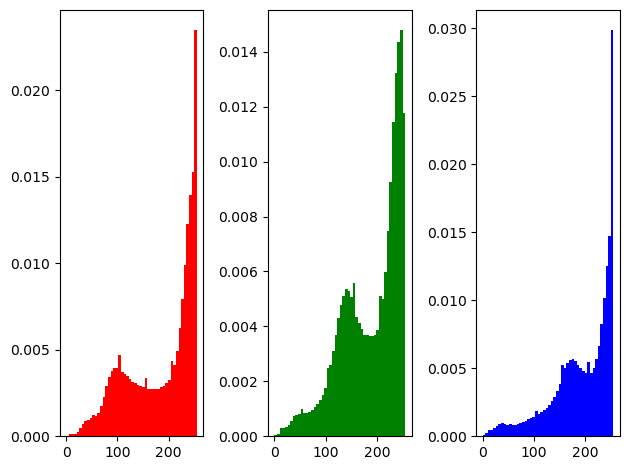

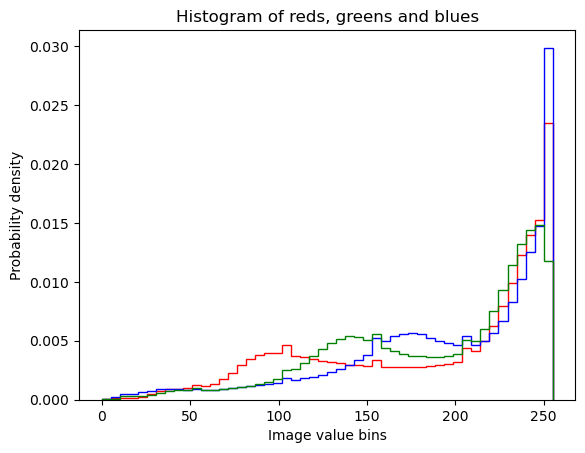

In [26]:
# We have never inspected the color cover image that we read in the first place. 
print(img.shape)
print(img.size)
print(img.dtype)

# We are going to plot histograms of red, green and blue channels separately.

nrows,ncols,nchannels = img.shape;
reds = np.copy(img[:,:,0]);   reds.shape = (nrows*ncols,);
greens = np.copy(img[:,:,1]); greens.shape = (nrows*ncols,);
blues = np.copy(img[:,:,2]);  blues.shape = (nrows*ncols,);

#Histogram
# All three histograms will be on one figure in a 1 by 3 layout
fig, axes = plt.subplots(1, 3, tight_layout=True);

n_bins = 50
counts_r, bins_r, patches_r = axes[0].hist(reds,   bins=n_bins, density=True, facecolor='r');
counts_g, bins_g, patches_g = axes[1].hist(greens, bins=n_bins, density=True, facecolor='g');
counts_b, bins_b, patches_b = axes[2].hist(blues,  bins=n_bins, density=True, facecolor='b');


# Let's now plot them all together
plt.figure()
plt.stairs(counts_r,bins_r,color ='r')
plt.stairs(counts_b,bins_b,color = 'b')
plt.stairs(counts_g,bins_g,color = 'g')
plt.title('Histogram of reds, greens and blues')
plt.ylabel('Probability density')
plt.xlabel('Image value bins')

# Cropping the image and inspecting a specific value

We create a new image by copying a subset of an existing one using NumPy command
numpy.copy().
Note that we imported numpy as 'np', so we call that function using the name 'np.copy'.

x 10 y 75 values [169 169 169]


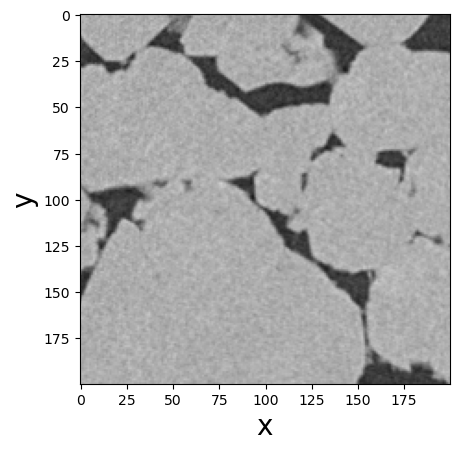

In [13]:
# Let's now crop the original image so we can inspect it better, and copy it into a new array.

sub = np.copy(img[0:200,100:300,:])
plt.imshow(sub)
plt.xlabel('x',fontsize=20)
plt.ylabel('y',fontsize=20)

# Example location value
x=10
y=75
print('x',x,'y',y,'values',sub[x,y,:])


Code below will show an interactive image using plotly.

Move around the image in the viewer and see how the values change. Relate those values to the histogram.

Move your cursor to location [x,y] indicated in the previous cell, and confirm that you see that same value.


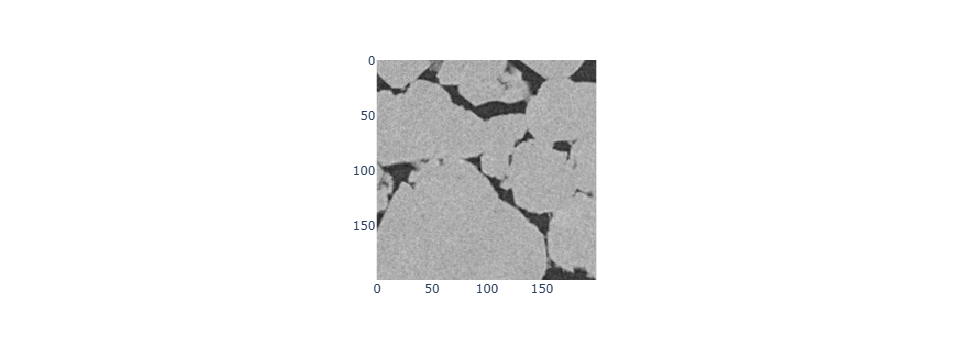

In [15]:
import plotly
import plotly.express as px
fig = px.imshow(sub)
fig.show()

## Saving images in one of the standard formats
Any of the images above can be saved in one of the standard image formats ('png','jpeg',tif',and so on) using io.save function.

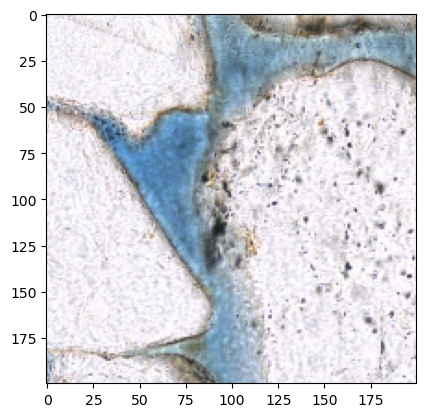

In [32]:
# If you want to save this file locally, then choose a name and use io.imsave similar to the commented command below.
# FORMAT: io.save(FILENAME,IMAGE_DATA)
filename = 'sandstone_thin_section_sub.png'
io.imsave(filename,sub)

#test the saved image
test = io.imread(filename)
plt.imshow(test)

## Exercises
1. Inspect and plot the min, max, mean value of the binarized slide through  a bead pack (example above).
2. Plot histogram for the same example.
3. Pick and plot a 200 by 200 subset of the same image.

## Example 5: Large SEM image of a sandstone

[Digital Porous Media Portal](https://www.digitalporousmedia.org) has a lot of published datasets and by navigating to the webpage of individual data, one can click on them and download to your computer. Depending on type of the file, the file can then be read in and manipulated in any software (including Python environments).

There is also [a webpage](https://web.corral.tacc.utexas.edu/digitalporousmedia/) that exposes all of the data via url and for 2D images, imread function can read directly from url. We will us that option here.


In [35]:
# This is a larger image, and the imread seems to take time and than gives me trouble. 
# You might need to wait a moment for the process to finish!
imgurl = "https://web.corral.tacc.utexas.edu/digitalporousmedia/DRP-256/Plug%2044/Plug%2044%20SEM/plug_44_image_13-0.png"

image = io.imread(imgurl)
plt.imshow(image)

# If the image is downloaded in the same directory as this Notebook, you can uncomment:
#download_path = "plug_44_image_13-0.png"
#image = io.imread(download_path)


DecompressionBombError: Image size (201326592 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.

You will notice that:
- the execution is "queued" (* appears next to the cell) because it takes a 20 seconds or more  to execute
- (on my laptop with 32GB of RAM - result vary by hardware/software -  it ultimately  fails with "DecompressionBombError". This is something to do with image size.
- - The loading fails after skimage tries a number of libraries to load the image (it goes down a list of available options). The last one points to the Pillow library that was ultimately called to read the image. 

The problem with this image is that is  too big for the defaults set by some Python distributions. Image is not unusually big for digital rock physics  - imaging (of any kind!) continuously improves at a pace faster than image processing ability!

- I have found the fix for Pillow library on stack overflow (https://stackoverflow.com/questions/51152059/pillow-in-python-wont-let-me-open-image-exceeds-limit), and below is the new code with that fix.
- Check the time it takes to read the image below.

### Changing settings for a successful reading of SEM image

After you read the image above, you can redo exercises we've gone through above with this image.

In [ ]:
# This is the fix for the built in maximum image size.
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

imgurl = "https://web.corral.tacc.utexas.edu/digitalporousmedia/DRP-256/Plug%2044/Plug%2044%20SEM/plug_44_image_13-0.png"
image   = io.imread(imgurl)

# Basic plot, using gray colors (note that in this image, any color would be fake)
plt.imshow(image,cmap='gray')


## Exercises

1. (_Inspect new image_)
Find a new 2D image example of a carbonate on [Digital Porous Media Portal](https://www.digitalporousmedia.org'), 
read it in, show it as well as plot its histogram. If you follow Published Datasets tab, there is a search function that can be useful.

2. (_Programming exercise reviewing how to create a function in Python_)
Based on the exercises above, create a histogram function in Python that produces either a single grayscale or a color histogram of the image (which is really just numpy array), 
and sets the plots either with the colors chosen above (or just the way you like them).  
    - The function needs to correctly recognize if the image has one channel, or three or more (i.e. it is color), and plot histogram accordingly. The fourth channel (transparency) should be ignored (and the function should comment why is that so). 
    - For now assume that any color image is RGB (and print a warning saying so). Default number of bins should be 256.
    - Test the function on the above examples.